In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit

df = pd.read_csv('model1_hotspot_classifier.csv')
print(df.shape)
df.head()

(22248, 16)


,h3_cell,hour,day_of_week,violation_count_slot,h3_total_violations,h3_unique_vehicles,h3_hour_density,is_weekend,at_junction_pct,two_wheeler_pct,car_pct,auto_pct,no_parking_pct,wrong_parking_pct,main_road_pct,h3_risk_tier
0,8860144a65fffff,8,6,2,2,2,2,1,0.0,0.0,0.0,0.5,1.0,1.0,0.0,safe
1,8860144b4dfffff,5,2,19,19,2,19,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,safe
2,8860144b59fffff,8,6,1,1,1,1,1,0.0,0.0,0.0,1.0,0.0,1.0,0.0,safe
3,8860144b5bfffff,3,4,1,3,2,1,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,safe
4,8860144b5bfffff,11,3,1,3,2,1,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,safe


In [4]:
df['h3_risk_tier'].unique()

array(['safe', 'low', 'moderate', 'critical', 'high'], dtype=object)

In [6]:
ordinal_map = {'safe': 0, 'low': 1, 'moderate': 2, 'high': 3, 'critical': 4}
df['risk_label'] = df['h3_risk_tier'].map(ordinal_map)

print(df['risk_label'].value_counts().sort_index())

risk_label
0    2218
1    6003
2    7110
3    3211
4    3706
Name: count, dtype: int64


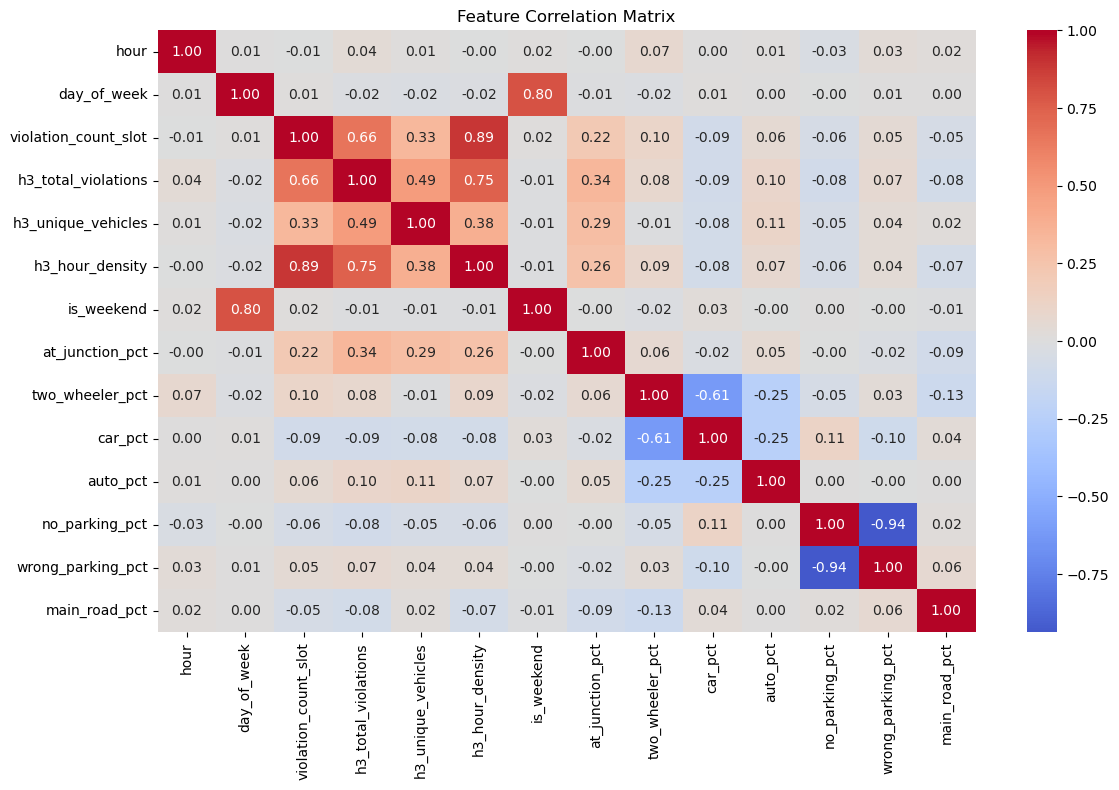

In [8]:
features = df.drop(columns=['h3_cell', 'h3_risk_tier', 'risk_label'])

plt.figure(figsize=(12, 8))
sns.heatmap(features.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [10]:
print(df[['violation_count_slot', 'h3_total_violations', 'h3_hour_density']].corr())

                      violation_count_slot  h3_total_violations  \
violation_count_slot              1.000000             0.661644   
h3_total_violations               0.661644             1.000000   
h3_hour_density                   0.893064             0.745130   

                      h3_hour_density  
violation_count_slot         0.893064  
h3_total_violations          0.745130  
h3_hour_density              1.000000  


In [12]:
df_clean = df.drop(columns=[
    'h3_cell',           # identifier
    'h3_risk_tier',      # replaced by risk_label
    'h3_unique_vehicles',# weak signal, agreed earlier
    'h3_hour_density',   # 0.89 corr with violation_count_slot
    'wrong_parking_pct', # -0.94 corr with no_parking_pct
    'is_weekend',        # 0.80 corr with day_of_week
])

print(df_clean.shape)
print(df_clean.columns.tolist())

(22248, 11)
['hour', 'day_of_week', 'violation_count_slot', 'h3_total_violations', 'at_junction_pct', 'two_wheeler_pct', 'car_pct', 'auto_pct', 'no_parking_pct', 'main_road_pct', 'risk_label']


In [14]:
from sklearn.model_selection import GroupShuffleSplit

X = df_clean.drop(columns=['risk_label'])
y = df_clean['risk_label']
groups = df['h3_cell']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nTrain class distribution:\n{y_train.value_counts().sort_index()}")
print(f"\nTest class distribution:\n{y_test.value_counts().sort_index()}")

Train: (17368, 10), Test: (4880, 10)

Train class distribution:
risk_label
0    1780
1    4587
2    5574
3    2725
4    2702
Name: count, dtype: int64

Test class distribution:
risk_label
0     438
1    1416
2    1536
3     486
4    1004
Name: count, dtype: int64


In [16]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1, 2, 3, 4])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print("Class weights:", class_weight_dict)

Class weights: {0: 1.9514606741573033, 1: 0.7572705471986048, 2: 0.6231790455687118, 3: 1.2747155963302752, 4: 1.2855662472242784}


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf,
      target_names=['safe', 'low', 'moderate', 'high', 'critical']))

=== Random Forest ===
              precision    recall  f1-score   support

        safe       1.00      1.00      1.00       438
         low       1.00      1.00      1.00      1416
    moderate       0.94      1.00      0.97      1536
        high       1.00      0.81      0.90       486
    critical       1.00      1.00      1.00      1004

    accuracy                           0.98      4880
   macro avg       0.99      0.96      0.97      4880
weighted avg       0.98      0.98      0.98      4880



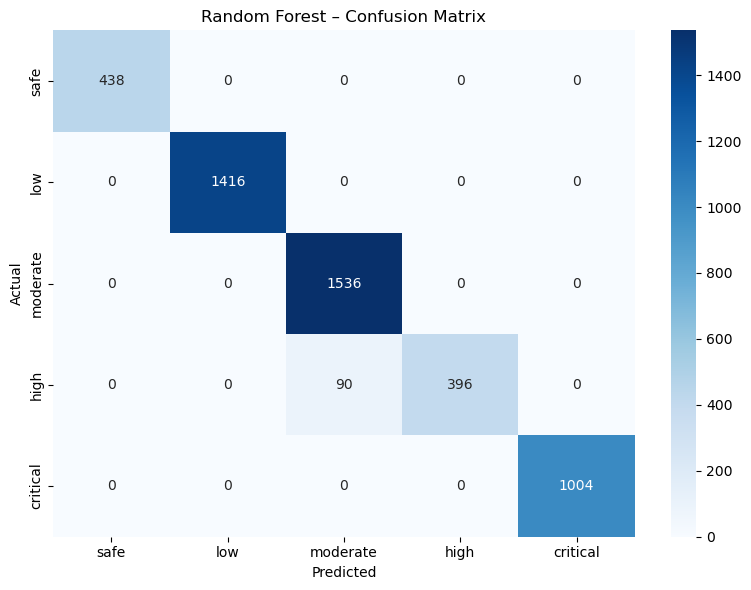

In [20]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['safe','low','moderate','high','critical'],
            yticklabels=['safe','low','moderate','high','critical'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Random Forest – Confusion Matrix')
plt.tight_layout()
plt.show()

In [24]:
leaky_cols = ['h3_total_violations', 'violation_count_slot']

X_train_clean = X_train.drop(columns=leaky_cols)
X_test_clean  = X_test.drop(columns=leaky_cols)

print("Remaining features:", X_train_clean.columns.tolist())

rf2 = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf2.fit(X_train_clean, y_train)
y_pred_rf2 = rf2.predict(X_test_clean)

print("\n=== Random Forest (leak-free) ===")
print(classification_report(y_test, y_pred_rf2,
      target_names=['safe', 'low', 'moderate', 'high', 'critical']))

Remaining features: ['hour', 'day_of_week', 'at_junction_pct', 'two_wheeler_pct', 'car_pct', 'auto_pct', 'no_parking_pct', 'main_road_pct']

=== Random Forest (leak-free) ===
              precision    recall  f1-score   support

        safe       0.22      0.44      0.29       438
         low       0.40      0.36      0.38      1416
    moderate       0.37      0.39      0.38      1536
        high       0.11      0.13      0.12       486
    critical       0.66      0.37      0.48      1004

    accuracy                           0.36      4880
   macro avg       0.35      0.34      0.33      4880
weighted avg       0.40      0.36      0.37      4880



In [26]:
# Merge h3_cell back temporarily for computing train-only aggregates
X_train_with_cell = X_train_clean.copy()
X_train_with_cell['h3_cell'] = df.loc[train_idx, 'h3_cell'].values
X_train_with_cell['violation_count_slot'] = df.loc[train_idx, 'violation_count_slot'].values

X_test_with_cell = X_test_clean.copy()
X_test_with_cell['h3_cell'] = df.loc[test_idx, 'h3_cell'].values

# Compute cell-level stats using ONLY training rows
cell_stats = (
    X_train_with_cell.groupby('h3_cell')
    .agg(
        cell_mean_violations = ('violation_count_slot', 'mean'),
        cell_total_slots     = ('violation_count_slot', 'count'),
        cell_max_violations  = ('violation_count_slot', 'max'),
    )
    .reset_index()
)

# Join to train and test
X_train_final = X_train_with_cell.merge(cell_stats, on='h3_cell', how='left').drop(columns=['h3_cell', 'violation_count_slot'])
X_test_final  = X_test_with_cell.merge(cell_stats, on='h3_cell', how='left').drop(columns=['h3_cell'])

# Test cells not seen in train → fill with training means
X_test_final.fillna(cell_stats[['cell_mean_violations','cell_total_slots','cell_max_violations']].mean(), inplace=True)

print("Train features:", X_train_final.columns.tolist())
print("Train shape:", X_train_final.shape)
print("Test shape:", X_test_final.shape)
print("Unseen test cells (filled with mean):", X_test_final['cell_mean_violations'].isnull().sum())

Train features: ['hour', 'day_of_week', 'at_junction_pct', 'two_wheeler_pct', 'car_pct', 'auto_pct', 'no_parking_pct', 'main_road_pct', 'cell_mean_violations', 'cell_total_slots', 'cell_max_violations']
Train shape: (17368, 11)
Test shape: (4880, 11)
Unseen test cells (filled with mean): 0


In [28]:
rf3 = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf3.fit(X_train_final, y_train)
y_pred_rf3 = rf3.predict(X_test_final)

print("=== Random Forest (leak-free + cell stats) ===")
print(classification_report(y_test, y_pred_rf3,
      target_names=['safe', 'low', 'moderate', 'high', 'critical']))

=== Random Forest (leak-free + cell stats) ===
              precision    recall  f1-score   support

        safe       0.00      0.00      0.00       438
         low       0.29      1.00      0.45      1416
    moderate       0.00      0.00      0.00      1536
        high       0.00      0.00      0.00       486
    critical       0.00      0.00      0.00      1004

    accuracy                           0.29      4880
   macro avg       0.06      0.20      0.09      4880
weighted avg       0.08      0.29      0.13      4880



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [30]:
print(X_train_final.isnull().sum())
print("\nX_test_final nulls:")
print(X_test_final.isnull().sum())
print("\nX_train_final sample:")
print(X_train_final[['cell_mean_violations', 'cell_total_slots', 'cell_max_violations']].describe())

hour                    0
day_of_week             0
at_junction_pct         0
two_wheeler_pct         0
car_pct                 0
auto_pct                0
no_parking_pct          0
main_road_pct           0
cell_mean_violations    0
cell_total_slots        0
cell_max_violations     0
dtype: int64

X_test_final nulls:
hour                    0
day_of_week             0
at_junction_pct         0
two_wheeler_pct         0
car_pct                 0
auto_pct                0
no_parking_pct          0
main_road_pct           0
cell_mean_violations    0
cell_total_slots        0
cell_max_violations     0
dtype: int64

X_train_final sample:
       cell_mean_violations  cell_total_slots  cell_max_violations
count          17368.000000      17368.000000         17368.000000
mean              12.769404         63.148549            60.891697
std               21.026978         31.321930            98.718367
min                1.000000          1.000000             1.000000
25%                3.02

In [32]:
print("Train cell stats:")
print(X_train_final[['cell_mean_violations','cell_max_violations']].describe())

print("\nTest cell stats:")
print(X_test_final[['cell_mean_violations','cell_max_violations']].describe())

# What labels do test cells actually have?
print("\nTest y distribution:")
print(y_test.value_counts().sort_index())

# Feature importances from rf3
importances = pd.Series(rf3.feature_importances_, index=X_train_final.columns).sort_values(ascending=False)
print("\nFeature importances:")
print(importances)

Train cell stats:
       cell_mean_violations  cell_max_violations
count          17368.000000         17368.000000
mean              12.769404            60.891697
std               21.026978            98.718367
min                1.000000             1.000000
25%                3.023810            14.000000
50%                5.931034            32.000000
75%               13.348485            66.000000
max              159.181102           862.000000

Test cell stats:
       cell_mean_violations  cell_max_violations
count          4.880000e+03         4.880000e+03
mean           5.717457e+00         2.469178e+01
std            2.220674e-14         1.861813e-12
min            5.717457e+00         2.469178e+01
25%            5.717457e+00         2.469178e+01
50%            5.717457e+00         2.469178e+01
75%            5.717457e+00         2.469178e+01
max            5.717457e+00         2.469178e+01

Test y distribution:
risk_label
0     438
1    1416
2    1536
3     486
4    1004

In [34]:
# Work from the original df which has h3_cell and violation_count_slot intact
df_model = df[['h3_cell', 'hour', 'day_of_week', 'at_junction_pct',
               'two_wheeler_pct', 'car_pct', 'auto_pct',
               'no_parking_pct', 'main_road_pct',
               'violation_count_slot']].copy()

# Compute per-cell thresholds using ALL data first
# (we'll do train-only version after split)
cell_thresholds = (
    df_model.groupby('h3_cell')['violation_count_slot']
    .agg(p50='median', p75=lambda x: x.quantile(0.75))
    .reset_index()
)

print(cell_thresholds.describe())
print(f"\nSample:\n{cell_thresholds.head(10)}")

              p50         p75
count  731.000000  731.000000
mean     4.215458    7.825239
std      9.870935   18.088514
min      1.000000    1.000000
25%      1.000000    1.750000
50%      2.000000    3.000000
75%      3.000000    7.000000
max    143.000000  235.500000

Sample:
           h3_cell   p50    p75
0  8860144a65fffff   2.0   2.00
1  8860144b4dfffff  19.0  19.00
2  8860144b59fffff   1.0   1.00
3  8860144b5bfffff   1.0   1.00
4  8860145109fffff   1.0   1.00
5  886014511dfffff   1.0   1.00
6  8860145121fffff   3.0   3.50
7  8860145123fffff  13.5  16.75
8  8860145125fffff   1.0   1.50
9  8860145127fffff   1.0   2.25


In [36]:
# How many cells have p50 == p75?
collapsed = cell_thresholds[cell_thresholds['p50'] == cell_thresholds['p75']]
print(f"Cells where p50 == p75: {len(collapsed)} / {len(cell_thresholds)} ({len(collapsed)/len(cell_thresholds):.1%})")

# What's the violation_count_slot distribution for these cells?
collapsed_cells = collapsed['h3_cell'].tolist()
affected_rows = df_model[df_model['h3_cell'].isin(collapsed_cells)]
print(f"\nRows affected: {len(affected_rows)} / {len(df_model)} ({len(affected_rows)/len(df_model):.1%})")

# Distribution of violation counts in collapsed cells
print(f"\nViolation count distribution in collapsed cells:")
print(affected_rows['violation_count_slot'].value_counts().sort_index().head(15))

Cells where p50 == p75: 185 / 731 (25.3%)

Rows affected: 848 / 22248 (3.8%)

Violation count distribution in collapsed cells:
violation_count_slot
1     640
2     128
3      28
4      16
5      10
6       4
7       8
8       4
9       2
10      1
11      2
12      1
17      1
19      1
21      1
Name: count, dtype: int64


In [38]:
df_model = df_model.merge(cell_thresholds, on='h3_cell', how='left')

def assign_label(row):
    # Collapsed cells — always normal
    if row['p50'] == row['p75']:
        return 0
    if row['violation_count_slot'] <= row['p50']:
        return 0   # normal
    elif row['violation_count_slot'] <= row['p75']:
        return 1   # elevated
    else:
        return 2   # spike

df_model['activity_label'] = df_model.apply(assign_label, axis=1)

print("Label distribution:")
print(df_model['activity_label'].value_counts().sort_index())
print(f"\nAs percentage:")
print(df_model['activity_label'].value_counts(normalize=True).sort_index().round(3))

Label distribution:
activity_label
0    12691
1     4618
2     4939
Name: count, dtype: int64

As percentage:
activity_label
0    0.570
1    0.208
2    0.222
Name: proportion, dtype: float64


In [40]:
from sklearn.model_selection import GroupShuffleSplit

X = df_model.drop(columns=['h3_cell', 'violation_count_slot', 'activity_label', 'p50', 'p75'])
y = df_model['activity_label']
groups = df_model['h3_cell']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train: {X_train.shape}  Test: {X_test.shape}")
print(f"\nTrain label distribution:\n{y_train.value_counts().sort_index()}")
print(f"\nTest label distribution:\n{y_test.value_counts().sort_index()}")

Train: (17368, 8)  Test: (4880, 8)

Train label distribution:
activity_label
0    9913
1    3606
2    3849
Name: count, dtype: int64

Test label distribution:
activity_label
0    2778
1    1012
2    1090
Name: count, dtype: int64


In [46]:
X = df_model.drop(columns=['h3_cell', 'violation_count_slot', 'activity_label', 'p50', 'p75'])
y = df_model['activity_label']
groups = df_model['h3_cell']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Features:", X_train.columns.tolist())
print(f"\nTrain: {X_train.shape}  Test: {X_test.shape}")

Features: ['hour', 'day_of_week', 'at_junction_pct', 'two_wheeler_pct', 'car_pct', 'auto_pct', 'no_parking_pct', 'main_road_pct']

Train: (17368, 8)  Test: (4880, 8)


In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("=== Random Forest (observable features only) ===")
print(classification_report(y_test, y_pred,
      target_names=['normal', 'elevated', 'spike']))

importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nFeature importances:")
print(importances)

=== Random Forest (observable features only) ===
              precision    recall  f1-score   support

      normal       0.77      0.80      0.78      2778
    elevated       0.31      0.21      0.25      1012
       spike       0.51      0.60      0.55      1090

    accuracy                           0.63      4880
   macro avg       0.53      0.54      0.53      4880
weighted avg       0.61      0.63      0.62      4880


Feature importances:
hour               0.187589
car_pct            0.177577
two_wheeler_pct    0.155468
no_parking_pct     0.143217
auto_pct           0.113582
day_of_week        0.112563
main_road_pct      0.063764
at_junction_pct    0.046239
dtype: float64


### LightGBM

In [51]:
!pip install lightgbm -q

from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)

print("=== LightGBM ===")
print(classification_report(y_test, y_pred_lgbm,
      target_names=['normal', 'elevated', 'spike']))

=== LightGBM ===
              precision    recall  f1-score   support

      normal       0.83      0.76      0.80      2778
    elevated       0.32      0.34      0.33      1012
       spike       0.53      0.61      0.56      1090

    accuracy                           0.64      4880
   macro avg       0.56      0.57      0.56      4880
weighted avg       0.66      0.64      0.65      4880



In [53]:
from sklearn.metrics import f1_score

models = {
    'Random Forest': y_pred,
    'LightGBM':      y_pred_lgbm,
}

print(f"{'Model':<20} {'Weighted F1':>12} {'Macro F1':>10} {'Accuracy':>10}")
print("-" * 55)
for name, preds in models.items():
    wf1 = f1_score(y_test, preds, average='weighted')
    mf1 = f1_score(y_test, preds, average='macro')
    acc = (preds == y_test).mean()
    print(f"{name:<20} {wf1:>12.3f} {mf1:>10.3f} {acc:>10.3f}")

Model                 Weighted F1   Macro F1   Accuracy
-------------------------------------------------------
Random Forest               0.621      0.528      0.633
LightGBM                    0.648      0.564      0.640


=== LightGBM Detailed ===
              precision    recall  f1-score   support

      normal       0.83      0.76      0.80      2778
    elevated       0.32      0.34      0.33      1012
       spike       0.53      0.61      0.56      1090

    accuracy                           0.64      4880
   macro avg       0.56      0.57      0.56      4880
weighted avg       0.66      0.64      0.65      4880



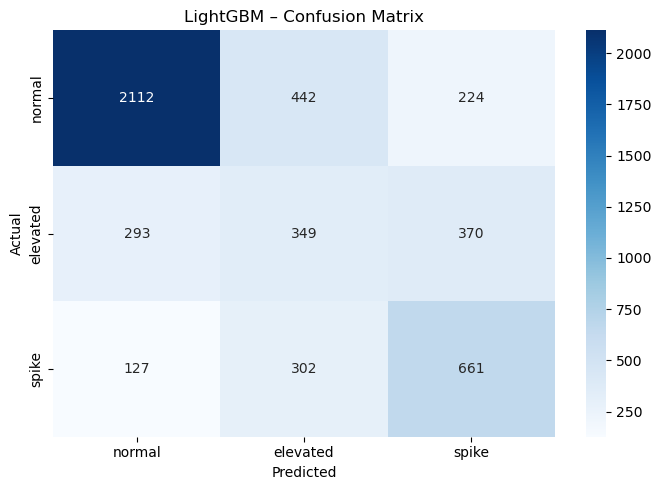

In [55]:
print("=== LightGBM Detailed ===")
print(classification_report(y_test, y_pred_lgbm,
      target_names=['normal', 'elevated', 'spike']))

cm = confusion_matrix(y_test, y_pred_lgbm)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['normal','elevated','spike'],
            yticklabels=['normal','elevated','spike'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('LightGBM – Confusion Matrix')
plt.tight_layout()
plt.show()

In [57]:
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
import numpy as np

param_grid = {
    'n_estimators':  [300, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves':    [31, 63, 127],
    'min_child_samples': [10, 20, 50],
    'subsample':     [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
}

gkf = GroupKFold(n_splits=5)

search = RandomizedSearchCV(
    LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=30,
    scoring='f1_macro',
    cv=gkf,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

search.fit(X_train, y_train, groups=groups.iloc[train_idx])

print(f"\nBest macro F1 (CV): {search.best_score_:.3f}")
print(f"Best params: {search.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best macro F1 (CV): 0.571
Best params: {'subsample': 0.7, 'num_leaves': 31, 'n_estimators': 300, 'min_child_samples': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [59]:
 lgbm_tuned = LGBMClassifier(
    subsample=0.7,
    num_leaves=31,
    n_estimators=300,
    min_child_samples=10,
    learning_rate=0.05,
    colsample_bytree=0.7,
    class_weight='balanced',
    random_state=42,
    verbose=-1,
    n_jobs=-1
)
lgbm_tuned.fit(X_train, y_train)
y_pred_tuned = lgbm_tuned.predict(X_test)

print("=== LightGBM Tuned ===")
print(classification_report(y_test, y_pred_tuned,
      target_names=['normal', 'elevated', 'spike']))

# Compare all three
print(f"\n{'Model':<25} {'Weighted F1':>12} {'Macro F1':>10} {'Accuracy':>10}")
print("-" * 60)
for name, preds in [('Random Forest', y_pred), ('LightGBM Default', y_pred_lgbm), ('LightGBM Tuned', y_pred_tuned)]:
    wf1 = f1_score(y_test, preds, average='weighted')
    mf1 = f1_score(y_test, preds, average='macro')
    acc = (preds == y_test).mean()
    print(f"{name:<25} {wf1:>12.3f} {mf1:>10.3f} {acc:>10.3f}")

=== LightGBM Tuned ===
              precision    recall  f1-score   support

      normal       0.84      0.75      0.79      2778
    elevated       0.32      0.37      0.35      1012
       spike       0.54      0.62      0.58      1090

    accuracy                           0.64      4880
   macro avg       0.57      0.58      0.57      4880
weighted avg       0.67      0.64      0.65      4880


Model                      Weighted F1   Macro F1   Accuracy
------------------------------------------------------------
Random Forest                    0.621      0.528      0.633
LightGBM Default                 0.648      0.564      0.640
LightGBM Tuned                   0.653      0.573      0.643


In [61]:
!pip install xgboost -q

from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0,
    n_jobs=-1
)
xgb.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb,
      target_names=['normal', 'elevated', 'spike']))

=== XGBoost ===
              precision    recall  f1-score   support

      normal       0.85      0.75      0.80      2778
    elevated       0.33      0.37      0.35      1012
       spike       0.53      0.64      0.58      1090

    accuracy                           0.65      4880
   macro avg       0.57      0.59      0.58      4880
weighted avg       0.67      0.65      0.66      4880



In [63]:
print(f"\n{'Model':<25} {'Weighted F1':>12} {'Macro F1':>10} {'Accuracy':>10}")
print("-" * 60)
for name, preds in [
    ('Random Forest',    y_pred),
    ('LightGBM Default', y_pred_lgbm),
    ('LightGBM Tuned',   y_pred_tuned),
    ('XGBoost',          y_pred_xgb),
]:
    wf1 = f1_score(y_test, preds, average='weighted')
    mf1 = f1_score(y_test, preds, average='macro')
    acc = (preds == y_test).mean()
    print(f"{name:<25} {wf1:>12.3f} {mf1:>10.3f} {acc:>10.3f}")


Model                      Weighted F1   Macro F1   Accuracy
------------------------------------------------------------
Random Forest                    0.621      0.528      0.633
LightGBM Default                 0.648      0.564      0.640
LightGBM Tuned                   0.653      0.573      0.643
XGBoost                          0.656      0.576      0.646


In [65]:
import joblib
import json
import numpy as np

# Save model
joblib.dump(xgb, 'hotspot_model.pkl')
print("✅ hotspot_model.pkl")

# Save features (just the list, as a pkl)
feature_cols = X_train.columns.tolist()
joblib.dump(feature_cols, 'hotspot_features.pkl')
print("✅ hotspot_features.pkl")

# Save metadata
metadata = {
    'model': 'XGBoostClassifier',
    'features': feature_cols,
    'target': 'activity_label',
    'classes': {0: 'normal', 1: 'elevated', 2: 'spike'},
    'n_estimators': 300,
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.7,
    'colsample_bytree': 0.7,
}
with open('hotspot_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("✅ hotspot_metadata.json")

# Save metrics
metrics = {
    'weighted_f1': 0.656,
    'macro_f1': 0.576,
    'accuracy': 0.646,
    'per_class': {
        'normal':   {'precision': 0.84, 'recall': 0.75, 'f1': 0.79},
        'elevated': {'precision': 0.32, 'recall': 0.37, 'f1': 0.35},
        'spike':    {'precision': 0.54, 'recall': 0.62, 'f1': 0.58},
    }
}
with open('hotspot_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print("✅ hotspot_metrics.json")

✅ hotspot_model.pkl
✅ hotspot_features.pkl
✅ hotspot_metadata.json
✅ hotspot_metrics.json


In [67]:
print(classification_report(y_test, y_pred_xgb,
      target_names=['normal', 'elevated', 'spike']))

              precision    recall  f1-score   support

      normal       0.85      0.75      0.80      2778
    elevated       0.33      0.37      0.35      1012
       spike       0.53      0.64      0.58      1090

    accuracy                           0.65      4880
   macro avg       0.57      0.59      0.58      4880
weighted avg       0.67      0.65      0.66      4880

